In [1]:
!pip install easyocr
!pip install imutils

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.9 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.9 MB 626.6 kB/s eta 0:00:04
   ------- -------------------------------- 0.5/2.9 MB 626.6 kB/s eta 0:00:04
   ------- -------------------------------- 0.5/2.9 MB 626.6 kB/s eta 0:00:04
   ---------- ----------------------------- 0.8/2.9 MB 621.6 kB/s eta 0:00:04
   ---------- ----------------------------- 0.8/2.9 MB 621.6 kB/s eta 0:00:04
   -------------- ------------------------- 1.0/2.9 MB 619.8 kB/s eta 0:00:03
   ------------------ --------------------- 1.3/2.9 MB 638.0 kB/s eta 0:00:03
   ------------------ --------------------- 1.3/2.9 MB 638.0 kB/s eta 0:00:03
   --------------------- ------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25891 sha256=a07304f47ffd8ed46580f2b7a5572995aa3c327c84e0fd6cc5a0a29e39c70b59
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\69\2c\66\f966db29490794305257ac3abfe71d4f963f5fc75ba0eb8eb7
Successfully built imutils



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import easyocr

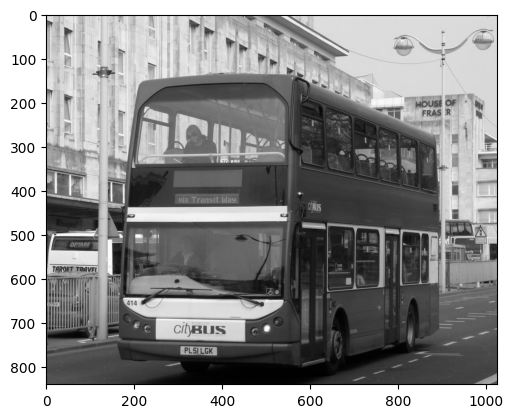

In [25]:
img = cv2.imread('assets/test_image2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

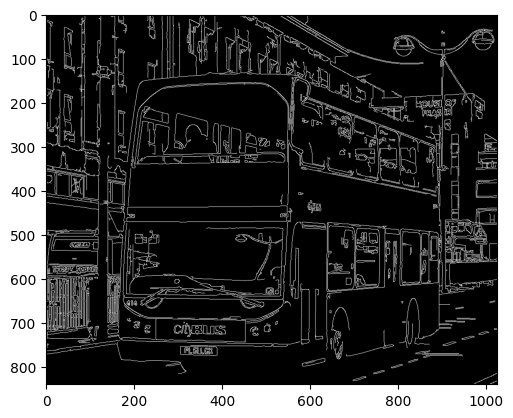

In [26]:
bfilter = cv2.bilateralFilter(gray, 11, 17, 17) 
edged = cv2.Canny(bfilter, 30, 200) 
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [27]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [28]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        location = approx
        break

In [29]:
location

array([[[249, 693]],

       [[451, 695]],

       [[452, 743]],

       [[251, 739]]], dtype=int32)

In [30]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0,255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

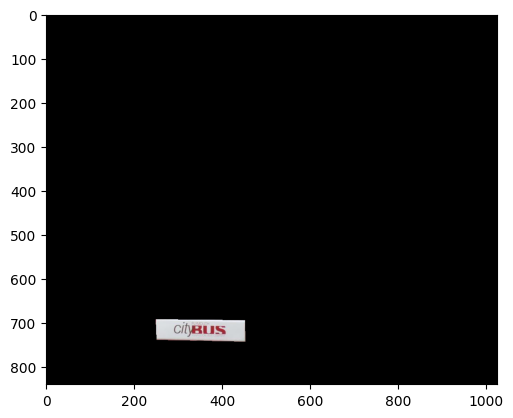

In [31]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [32]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

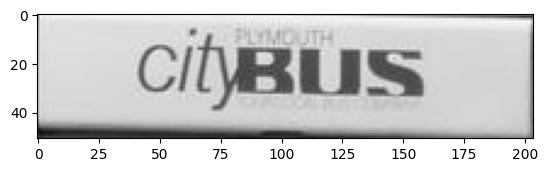

In [33]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

In [34]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)
result

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[np.int32(32), 0],
   [np.int32(167), 0],
   [np.int32(167), np.int32(49)],
   [np.int32(32), np.int32(49)]],
  'citybus',
  np.float64(0.47603570285555696))]

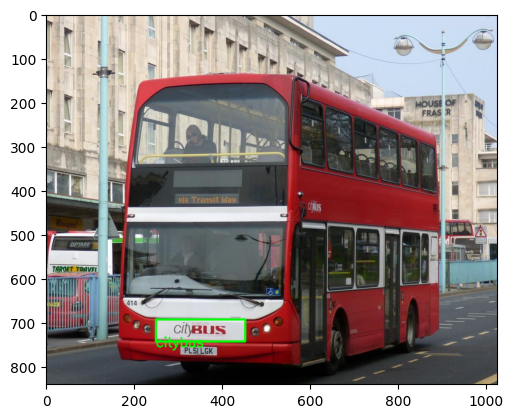

In [35]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))